X_train的形状是: (307, 2)
X_val的形状是: (307, 2)
y_val的形状是:  (307,)


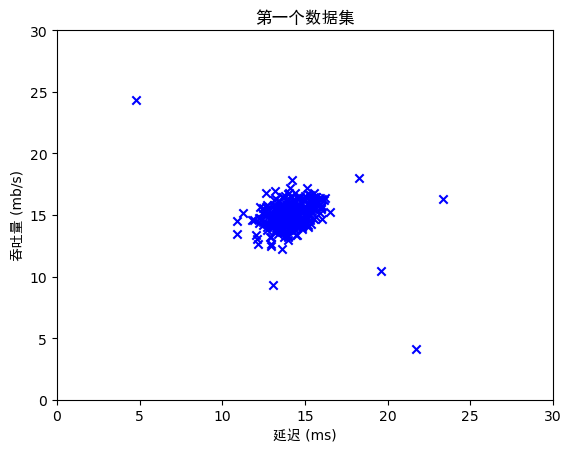

每个特征的均值: [14.11222578 14.99771051]
每个特征的方差: [1.83263141 1.70974533]
所有测试通过！
通过交叉验证找到的最佳阈值: 8.990853e-05
交叉验证集上的最佳F1分数: 0.875000
所有测试通过！
X_train_high的形状是: (1000, 11)
X_val_high的形状是: (100, 11)
y_val_high的形状是:  (100,)
通过交叉验证找到的最佳阈值: 1.377229e-18
交叉验证集上的最佳F1分数: 0.615385
发现的异常点数量: 117


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib inline
# 设置中文字体
plt.rcParams["font.family"] = ["sans-serif","SimHei"]
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 加载数据集
X_train, X_val, y_val = load_data()

print('X_train的形状是:', X_train.shape)
print('X_val的形状是:', X_val.shape)
print('y_val的形状是: ', y_val.shape)

# 创建数据的散点图，使用蓝色"x"作为标记
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# 设置标题
plt.title("第一个数据集")
# 设置y轴标签
plt.ylabel('吞吐量 (mb/s)')
# 设置x轴标签
plt.xlabel('延迟 (ms)')
# 设置坐标轴范围
plt.axis([0, 30, 0, 30])
plt.show()

def estimate_gaussian(X): 
    """
    计算数据集中所有特征的均值和方差
    
    参数:
        X (ndarray): (m, n) 数据矩阵，m个样本，n个特征
    
    返回:
        mu (ndarray): (n,) 每个特征的均值
        var (ndarray): (n,) 每个特征的方差
    """

    m, n = X.shape  # m是样本数，n是特征数
    
    ### 开始代码 ###
    # 计算每个特征的均值（沿样本轴计算）
    mu = np.mean(X, axis=0)
    # 计算每个特征的方差（使用总体方差，除以m而非m-1）
    var = np.var(X, axis=0)
    ### 结束代码 ###
        
    return mu, var

# 估计训练集的高斯分布参数
mu, var = estimate_gaussian(X_train)              

print("每个特征的均值:", mu)
print("每个特征的方差:", var)
    
# 单元测试
from public_tests import estimate_gaussian_test
estimate_gaussian_test(estimate_gaussian)

# 计算训练集样本的多元高斯概率密度
p = multivariate_gaussian(X_train, mu, var)

# 可视化高斯分布拟合结果
visualize_fit(X_train, mu, var)

def select_threshold(y_val, p_val): 
    """
    基于验证集的概率结果(p_val)和真实标签(y_val)找到最佳异常检测阈值
    
    参数:
        y_val (ndarray): 验证集的真实标签（1表示异常，0表示正常）
        p_val (ndarray): 验证集样本的概率密度
        
    返回:
        epsilon (float): 选择的阈值
        F1 (float): 使用该阈值得到的F1分数
    """ 

    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    # 计算步长，将概率范围分为1000个区间
    step_size = (max(p_val) - min(p_val)) / 1000
    
    # 遍历所有可能的阈值
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
        ### 开始代码 ###
        # 预测异常：概率小于阈值的为异常(1)，否则为正常(0)
        predictions = (p_val < epsilon).astype(int)
        
        # 计算真阳性(TP)：真实异常且被预测为异常
        TP = np.sum((predictions == 1) & (y_val == 1))
        # 计算假阳性(FP)：真实正常但被预测为异常
        FP = np.sum((predictions == 1) & (y_val == 0))
        # 计算假阴性(FN)：真实异常但被预测为正常
        FN = np.sum((predictions == 0) & (y_val == 1))
        
        # 计算精确率(precision)和召回率(recall)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        # 计算F1分数
        F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        ### 结束代码 ###
        
        # 更新最佳阈值和对应的F1分数
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
        
    return best_epsilon, best_F1

# 计算验证集样本的概率密度
p_val = multivariate_gaussian(X_val, mu, var)
# 选择最佳阈值
epsilon, F1 = select_threshold(y_val, p_val)

print('通过交叉验证找到的最佳阈值: %e' % epsilon)
print('交叉验证集上的最佳F1分数: %f' % F1)
    
# 单元测试
from public_tests import select_threshold_test
select_threshold_test(select_threshold)

# 找到训练集中的异常点
outliers = p < epsilon

# 可视化拟合结果
visualize_fit(X_train, mu, var)

# 用红色圆圈标记异常点
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize=10, markerfacecolor='none', markeredgewidth=2)

# 加载高维数据集
X_train_high, X_val_high, y_val_high = load_data_multi()

print('X_train_high的形状是:', X_train_high.shape)
print('X_val_high的形状是:', X_val_high.shape)
print('y_val_high的形状是: ', y_val_high.shape)

# 估计高维数据的高斯分布参数
mu_high, var_high = estimate_gaussian(X_train_high)

# 计算训练集的概率密度
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# 计算验证集的概率密度
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# 找到最佳阈值
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('通过交叉验证找到的最佳阈值: %e' % epsilon_high)
print('交叉验证集上的最佳F1分数: %f' % F1_high)
print('发现的异常点数量: %d' % sum(p_high < epsilon_high))